In [16]:
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [23]:
def plot_tsp_solution(json_path):
    # 1. Wczytanie danych
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Błąd: Nie znaleziono pliku {json_path}")
        return

    nodes = data['nodes']
    tour = data['tour']
    total_dist = data['total_distance']
    total_gain = data['total_gain']

    # Mapowanie danych dla łatwiejszego dostępu
    node_map = {n['id']: n for n in nodes}
    
    # 2. Przygotowanie współrzędnych trasy (z zamknięciem cyklu)
    x_tour = [node_map[idx]['x'] for idx in tour]
    y_tour = [node_map[idx]['y'] for idx in tour]
    x_tour.append(x_tour[0])  # Powrót do startu
    y_tour.append(y_tour[0])

    # 3. Przygotowanie danych wszystkich punktów
    all_x = [n['x'] for n in nodes]
    all_y = [n['y'] for n in nodes]
    all_gains = [n['gain'] for n in nodes]

    plt.figure(figsize=(12, 9))

    # --- RYSOWANIE KRAWĘDZI (TRASY) ---
    plt.plot(x_tour, y_tour, color='gray', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1, label='Trasa')
    
    # Opcjonalnie: strzałki pokazujące kierunek
    for i in range(len(x_tour) - 1):
        plt.arrow(x_tour[i], y_tour[i], (x_tour[i+1] - x_tour[i])*0.1, (y_tour[i+1] - y_tour[i])*0.1, 
                  shape='full', lw=0, length_includes_head=True, head_width=0.2, color='black', alpha=0.4)

    # --- RYSOWANIE WIERZCHOŁKÓW ---
    # Skalowanie wielkości punktów na podstawie zysku (np. od 50 do 300 jednostek)
    min_g, max_g = min(all_gains), max(all_gains)
    sizes = [((g - min_g) / (max_g - min_g + 1e-9) * 250) + 50 for g in all_gains]

    # Użycie mapy kolorów 'viridis' (od fioletu przez turkus do żółtego)
    scatter = plt.scatter(all_x, all_y, 
                          s=sizes, 
                          c=all_gains, 
                          cmap='viridis', 
                          edgecolors='white', 
                          linewidth=1, 
                          zorder=2)

    # Dodanie etykiet ID przy punktach
    # for n in nodes:
    #     plt.text(n['x'], n['y'] + 0.3, str(n['id']), fontsize=8, ha='center', weight='bold')

    # 4. Dodatki (Legenda, Colorbar)
    cbar = plt.colorbar(scatter)
    cbar.set_label('Zysk (Gain)', rotation=270, labelpad=15)
    
    plt.title(f"{json_path} | Dystans: {total_dist:.2f} | Zysk: {total_gain:.2f}" , fontsize=14)
    plt.xlabel("Współrzędna X")
    plt.ylabel("Współrzędna Y")
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.show()


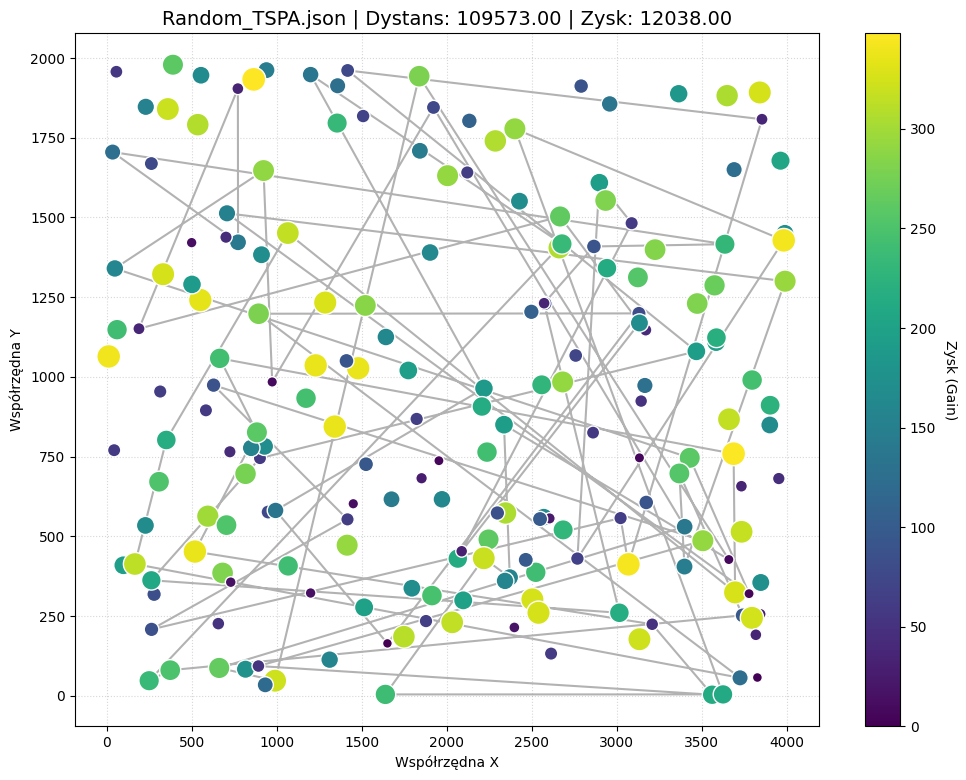

In [27]:
plot_tsp_solution("Random_TSPA.json")

# plot_tsp_solution("2regret_with_profit_TSPA.json")
# plot_tsp_solution("2regret_without_profit_TSPA.json")

# plot_tsp_solution("GC_with_profit_TSPA.json")
# plot_tsp_solution("GC_without_profit_TSPA.json")

# plot_tsp_solution("NN_with_profit_TSPA.json")
# plot_tsp_solution("NN_without_profit_TSPA.json")